# 🌲 ForestGuard: Wildlife vs Threat Detection

## 1. Setup & Imports

In [5]:
import os
import json
import shutil
import zipfile
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import librosa
import librosa.display

# Set style
sns.set_theme(style="whitegrid")

# 🛠️ Robust Path Detection
BASE_DIR = Path.cwd()

# Check if we're in the project root
if not (BASE_DIR / "dataset").exists():
    # Try parent directory
    if (BASE_DIR.parent / "dataset").exists():
        BASE_DIR = BASE_DIR.parent
        print(f"📂 Adjusted BASE_DIR to parent: {BASE_DIR}")
    else:
        raise FileNotFoundError(
            "Could not find 'dataset' folder. Please run this notebook from the project root."
        )

# Define all paths using Path objects (no string escape issues)
RAW_DIR = BASE_DIR / "dataset" / "raw"
ESC50_DIR = BASE_DIR / "dataset"
CURATED_DIR = BASE_DIR / "dataset" / "curated"
PROCESSED_DIR = BASE_DIR / "dataset" / "processed"
MODELS_DIR = BASE_DIR / "models"

# Create output directories
for d in [CURATED_DIR / "wildlife", CURATED_DIR / "threat", PROCESSED_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Debug: Print paths
print(f"✅ BASE_DIR: {BASE_DIR}")
print(f"✅ RAW_DIR: {RAW_DIR}")
print(f"✅ Zip exists: {(RAW_DIR / 'environmental-sound-classification-50.zip').exists()}")

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Running on: {DEVICE}")

✅ BASE_DIR: d:\CDAC_PROJECT\forestguard
✅ RAW_DIR: d:\CDAC_PROJECT\forestguard\dataset\raw
✅ Zip exists: True
🚀 Running on: cpu


## 2. Data Extraction

In [6]:
zip_path = RAW_DIR / "environmental-sound-classification-50.zip"
csv_path = ESC50_DIR / "esc50.csv"

# Extract if needed
if not csv_path.exists():
    if zip_path.exists():
        print("📦 Extracting ESC-50 dataset...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(ESC50_DIR.parent)
        print("✅ Extraction complete.")
        
        # Verify extraction
        if not csv_path.exists():
            raise FileNotFoundError(
                f"esc50.csv not found after extraction. Check {ESC50_DIR} contents."
            )
    else:
        raise FileNotFoundError(
            f"Zip file not found at {zip_path}. Please download ESC-50 dataset."
        )
else:
    print("✅ Dataset already extracted.")

print(f"✅ CSV path: {csv_path}")

✅ Dataset already extracted.
✅ CSV path: d:\CDAC_PROJECT\forestguard\dataset\esc50.csv


## 3. EDA 1: Metadata Exploration

In [7]:
# Load metadata
df = pd.read_csv(csv_path)
print(f"📊 Total samples: {len(df)}")
print(f"📂 Columns: {list(df.columns)}")
df.head()

📊 Total samples: 2000
📂 Columns: ['filename', 'fold', 'target', 'category', 'esc10', 'src_file', 'take']


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


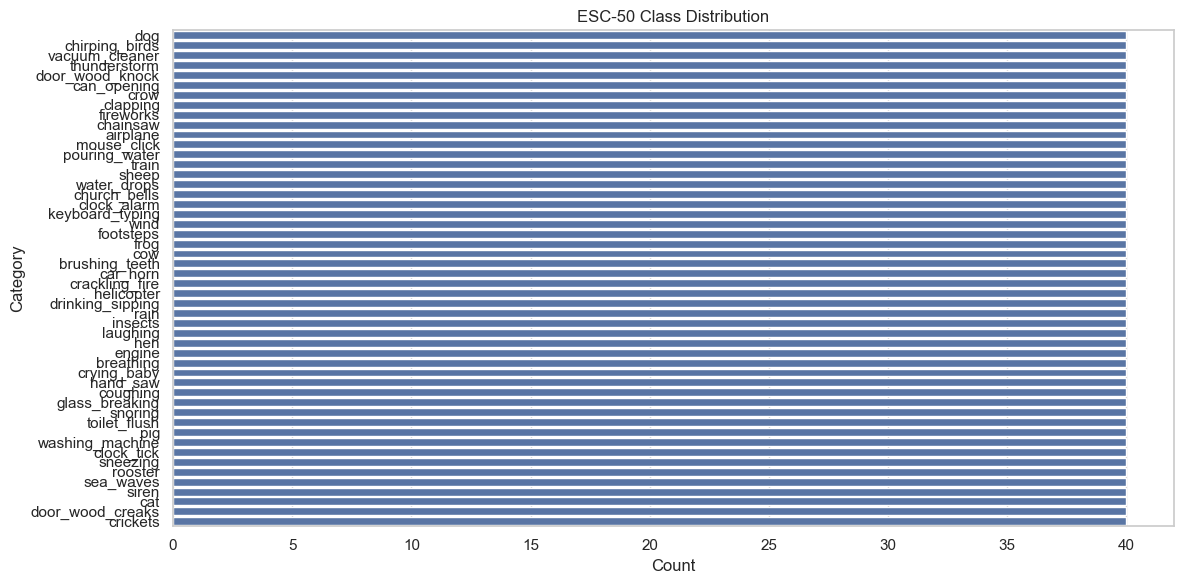

In [8]:
# Class distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='category', order=df['category'].value_counts().index)
plt.title('ESC-50 Class Distribution')
plt.xlabel('Count')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

In [9]:
# Fold distribution
print("📁 Fold distribution:")
print(df['fold'].value_counts().sort_index())

# ESC-10 subset
print(f"\n🔟 ESC-10 samples: {df['esc10'].sum()}")

📁 Fold distribution:
fold
1    400
2    400
3    400
4    400
5    400
Name: count, dtype: int64

🔟 ESC-10 samples: 400


## 4. Data Curation

In [10]:
# Define target classes
WILDLIFE_CLASSES = ["dog", "frog", "crow", "crickets", "chirping_birds"]
THREAT_CLASSES = ["chainsaw", "siren", "engine", "helicopter"]
SELECTED_CLASSES = WILDLIFE_CLASSES + THREAT_CLASSES

# Filter dataframe
forest_df = df[df["category"].isin(SELECTED_CLASSES)].copy()
forest_df["label"] = forest_df["category"].apply(
    lambda x: 0 if x in WILDLIFE_CLASSES else 1
)

print(f"🎯 Selected samples: {len(forest_df)}")
print(f"📊 Class distribution:\n{forest_df['label'].value_counts().sort_index()}")
forest_df.head()

🎯 Selected samples: 360
📊 Class distribution:
label
0    200
1    160
Name: count, dtype: int64


,filename,fold,target,category,esc10,src_file,take,label
0,1-100032-A-0.wav,1,0,dog,True,100032,A,0
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A,0
8,1-103298-A-9.wav,1,9,crow,False,103298,A,0
14,1-110389-A-0.wav,1,0,dog,True,110389,A,0
24,1-116765-A-41.wav,1,41,chainsaw,True,116765,A,1


In [19]:
# 🛠️ Robust path redefinition to avoid stale kernel state
ESC50_DIR = BASE_DIR / "dataset"  # ✅ Fixed: ESC-50 files are directly in dataset/
audio_dir = BASE_DIR / "dataset" / "audio" / "audio"

# Debug: Verify paths and data
print(f"📂 ESC50_DIR: {ESC50_DIR}")
print(f"📂 audio_dir: {audio_dir}")
print(f"✅ audio_dir exists: {audio_dir.exists()}")
print(f"🔢 Audio files in audio_dir: {len(list(audio_dir.glob('*.wav')))}")
print(f"📊 forest_df rows: {len(forest_df)}")

# Check first sample
if len(forest_df) > 0:
    sample_file = forest_df.iloc[0]["filename"]
    sample_src = audio_dir / Path(sample_file).name
    print(f"🔍 Sample filename: {sample_file}")
    print(f"🔍 Sample src: {sample_src}")
    print(f"✅ Sample src exists: {sample_src.exists()}")

# Ensure curated folders exist
(CURATED_DIR / "wildlife").mkdir(parents=True, exist_ok=True)
(CURATED_DIR / "threat").mkdir(parents=True, exist_ok=True)

# Copy files
print("\n📂 Organizing curated dataset...")
copied_count = 0
for _, row in tqdm(forest_df.iterrows(), total=len(forest_df), desc="Copying files"):
    src = audio_dir / Path(row["filename"]).name
    dst_folder = CURATED_DIR / ("wildlife" if row["label"] == 0 else "threat")
    dst = dst_folder / row["filename"]
    
    if src.exists():
        if not dst.exists():
            shutil.copy2(src, dst)
            copied_count += 1
    else:
        print(f"⚠️ Source not found: {src}")

# Verify curated files
wildlife_count = len(list((CURATED_DIR / "wildlife").glob("*.wav")))
threat_count = len(list((CURATED_DIR / "threat").glob("*.wav")))

print(f"\n✅ Copied {copied_count} files")
print(f"✅ Curated wildlife files: {wildlife_count}")
print(f"✅ Curated threat files: {threat_count}")

📂 ESC50_DIR: d:\CDAC_PROJECT\forestguard\dataset
📂 audio_dir: d:\CDAC_PROJECT\forestguard\dataset\audio\audio
✅ audio_dir exists: True
🔢 Audio files in audio_dir: 2000
📊 forest_df rows: 360
🔍 Sample filename: 1-100032-A-0.wav
🔍 Sample src: d:\CDAC_PROJECT\forestguard\dataset\audio\audio\1-100032-A-0.wav
✅ Sample src exists: True

📂 Organizing curated dataset...


Copying files:   0%|          | 0/360 [00:00<?, ?it/s]

Copying files: 100%|██████████| 360/360 [00:09<00:00, 37.11it/s]


✅ Copied 360 files
✅ Curated wildlife files: 200
✅ Curated threat files: 160


## 5. EDA 2: Curated Dataset Inspection

C:\Users\ircpr\AppData\Local\Temp\ipykernel_18208\1119038745.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Wildlife', 'Threat'], y=[wildlife_count, threat_count], palette=['green', 'red'], ax=ax)


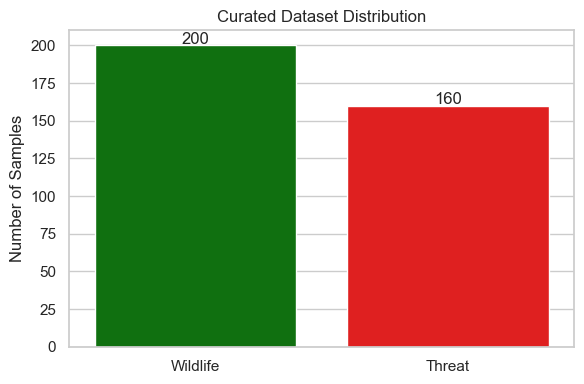

In [20]:
# Visualize curated class distribution
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=['Wildlife', 'Threat'], y=[wildlife_count, threat_count], palette=['green', 'red'], ax=ax)
ax.set_title('Curated Dataset Distribution')
ax.set_ylabel('Number of Samples')
for i, v in enumerate([wildlife_count, threat_count]):
    ax.text(i, v + 1, str(v), ha='center')
plt.tight_layout()
plt.show()

In [21]:
# Listen to a sample (optional)
import IPython.display as ipd

sample_wildlife = list((CURATED_DIR / "wildlife").glob("*.wav"))[0]
sample_threat = list((CURATED_DIR / "threat").glob("*.wav"))[0]

print(f"🐸 Wildlife sample: {sample_wildlife.name}")
ipd.display(ipd.Audio(sample_wildlife))

print(f"⚠️ Threat sample: {sample_threat.name}")
ipd.display(ipd.Audio(sample_threat))

🐸 Wildlife sample: 1-100032-A-0.wav


⚠️ Threat sample: 1-116765-A-41.wav


## 6. Feature Extraction

In [22]:
# Configuration
SR = 22050
N_MELS = 128
FMAX = 8000
TARGET_FRAMES = 216

def extract_mel_spectrogram(file_path):
    y, sr = librosa.load(file_path, sr=SR)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, fmax=FMAX)
    mel_db = librosa.power_to_db(mel_spec, ref=np.max)
    
    # Pad or truncate
    if mel_db.shape[1] < TARGET_FRAMES:
        pad_width = TARGET_FRAMES - mel_db.shape[1]
        mel_db = np.pad(mel_db, ((0, 0), (0, pad_width)), mode="constant")
    else:
        mel_db = mel_db[:, :TARGET_FRAMES]
    
    return mel_db

In [23]:
# Extract features
X, y = [], []

for label, class_name in enumerate(["wildlife", "threat"]):
    class_dir = CURATED_DIR / class_name
    wav_files = sorted(class_dir.glob("*.wav"))
    
    print(f"🔍 Processing {class_name}: {len(wav_files)} files")
    
    for wav_file in tqdm(wav_files, desc=f"Extracting {class_name}"):
        try:
            mel = extract_mel_spectrogram(wav_file)
            X.append(mel)
            y.append(label)
        except Exception as e:
            print(f"⚠️ Error processing {wav_file.name}: {e}")

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int64)

print(f"\n✅ X shape: {X.shape}")
print(f"✅ y shape: {y.shape}")

assert X.shape[0] > 0, "❌ No features extracted! Check curated files."

🔍 Processing wildlife: 200 files


Extracting wildlife: 100%|██████████| 200/200 [00:13<00:00, 14.30it/s]


🔍 Processing threat: 160 files


Extracting threat: 100%|██████████| 160/160 [00:06<00:00, 24.19it/s]


✅ X shape: (360, 128, 216)
✅ y shape: (360,)


In [24]:
# Train/Val split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Compute normalization stats from training set
mean_val = np.mean(X_train)
std_val = np.std(X_train)

print(f"📊 Mean: {mean_val:.6f}, Std: {std_val:.6f}")

# Save processed data
np.save(PROCESSED_DIR / "X_train.npy", X_train)
np.save(PROCESSED_DIR / "X_val.npy", X_val)
np.save(PROCESSED_DIR / "y_train.npy", y_train)
np.save(PROCESSED_DIR / "y_val.npy", y_val)
np.savez(PROCESSED_DIR / "norm_stats.npz", mean=mean_val, std=std_val)

# Save label map
label_map = {0: "Wildlife", 1: "Threat"}
with open(MODELS_DIR / "label_map.json", "w") as f:
    json.dump(label_map, f, indent=4)

print("✅ Processed data saved.")

📊 Mean: -43.603737, Std: 18.599327
✅ Processed data saved.


## 7. EDA 3: Feature Visualization

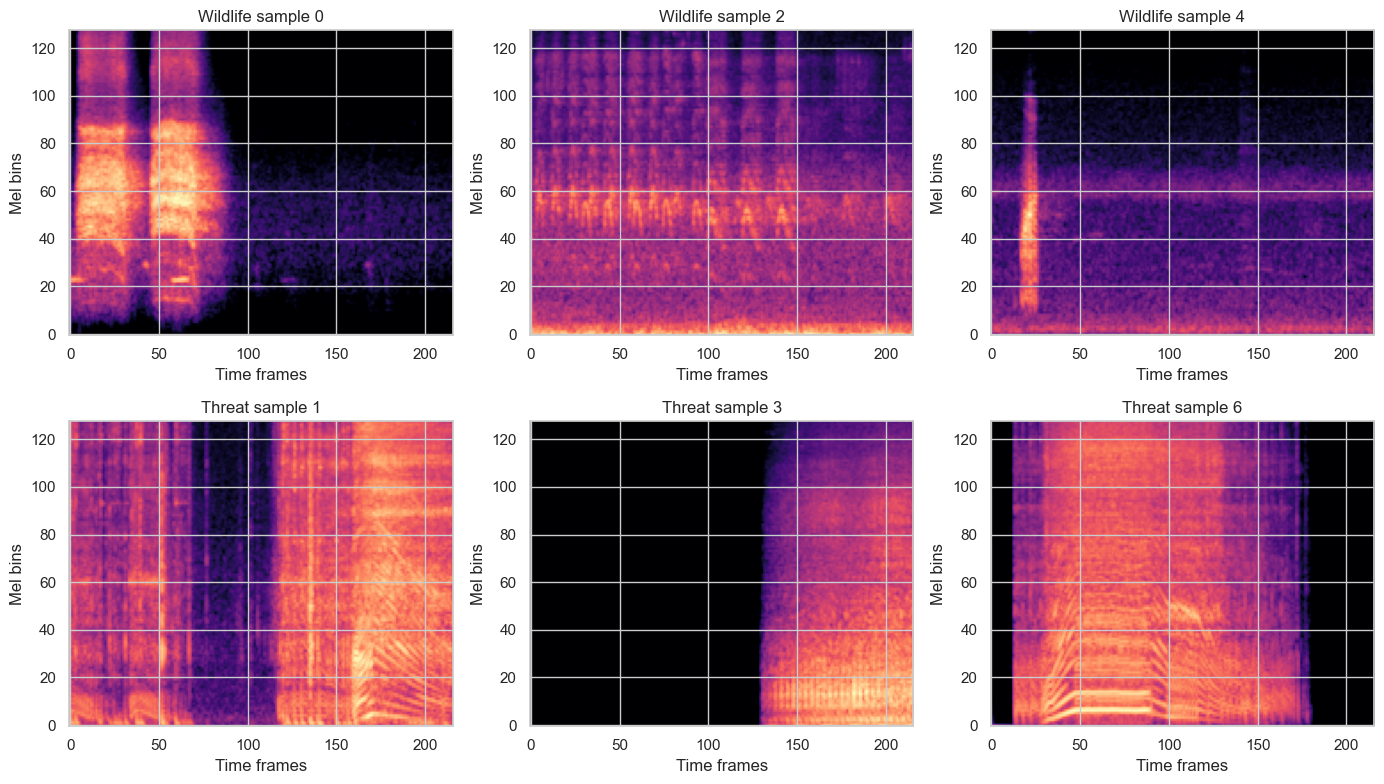

In [25]:
# Visualize sample spectrograms
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
wildlife_ids = np.where(y_train == 0)[0][:3]
threat_ids = np.where(y_train == 1)[0][:3]

for col, idx in enumerate(wildlife_ids):
    axes[0, col].imshow(X_train[idx], aspect="auto", origin="lower", cmap="magma")
    axes[0, col].set_title(f"Wildlife sample {idx}")
    axes[0, col].set_xlabel("Time frames")
    axes[0, col].set_ylabel("Mel bins")

for col, idx in enumerate(threat_ids):
    axes[1, col].imshow(X_train[idx], aspect="auto", origin="lower", cmap="magma")
    axes[1, col].set_title(f"Threat sample {idx}")
    axes[1, col].set_xlabel("Time frames")
    axes[1, col].set_ylabel("Mel bins")

plt.tight_layout()
plt.show()

📈 Feature Statistics:
  Min value: -80.00
  Max value: 0.00
  Mean value: -43.60
  Std value: 18.60


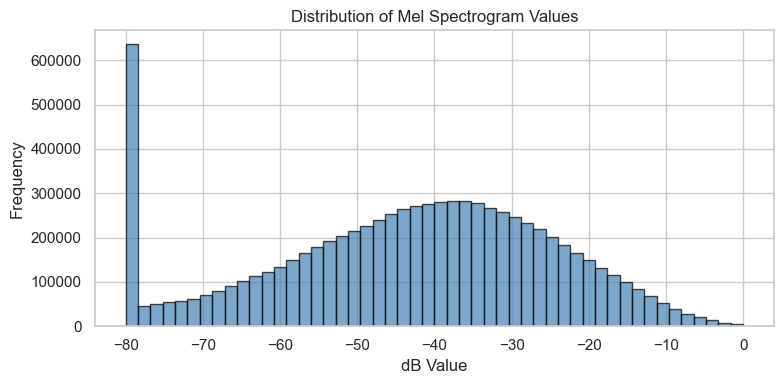

In [26]:
# Feature statistics
print("📈 Feature Statistics:")
print(f"  Min value: {X_train.min():.2f}")
print(f"  Max value: {X_train.max():.2f}")
print(f"  Mean value: {X_train.mean():.2f}")
print(f"  Std value: {X_train.std():.2f}")

# Histogram of pixel values
plt.figure(figsize=(8, 4))
plt.hist(X_train.flatten(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Mel Spectrogram Values')
plt.xlabel('dB Value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## 8. Model Definition

**Note**: This architecture matches the deployment model in `app.py`.

In [51]:
class ForestGuardCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 24, kernel_size=3, padding=1),
            nn.BatchNorm2d(24),
            nn.ReLU(),  # Changed from GELU to ReLU
            nn.Conv2d(24, 24, kernel_size=3, padding=1),
            nn.BatchNorm2d(24),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),  # Increased from 0.15
            
            nn.Conv2d(24, 48, kernel_size=3, padding=1),
            nn.BatchNorm2d(48),
            nn.ReLU(),
            nn.Conv2d(48, 48, kernel_size=3, padding=1),
            nn.BatchNorm2d(48),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.35),  # Increased from 0.20
            
            nn.Conv2d(48, 96, kernel_size=3, padding=1),
            nn.BatchNorm2d(96),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(96 * 4 * 4, 96),
            nn.ReLU(),
            nn.Dropout(0.5),  # Increased from 0.35
            nn.Linear(96, 2),
        )
    
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = ForestGuardCNN().to(DEVICE)
print(model)


total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n📊 Total parameters: {total_params:,}")
print(f"📊 Trainable parameters: {trainable_params:,}")

ForestGuardCNN(
  (features): Sequential(
    (0): Conv2d(1, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.25, inplace=False)
    (8): Conv2d(24, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Dropout(p=0.35, 

## 9. Training Setup

In [52]:
class SpectrogramDataset(Dataset):
    def __init__(self, features, labels, mean, std):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.mean = mean
        self.std = std
    
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        x = self.features[idx]
        x = (x - self.mean) / (self.std + 1e-8)
        return x.unsqueeze(0), self.labels[idx]

train_dataset = SpectrogramDataset(X_train, y_train, mean_val, std_val)
val_dataset = SpectrogramDataset(X_val, y_val, mean_val, std_val)

BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"📦 Train batches: {len(train_loader)}")
print(f"📦 Val batches: {len(val_loader)}")

📦 Train batches: 18
📦 Val batches: 5


In [53]:
# Improved hyperparameters to reduce overfitting
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=5e-3)  # Lower LR, higher weight decay
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25, eta_min=1e-6)  # Smoother LR schedule

## 10. Training Loop

In [54]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()
    
    total_loss, correct, total = 0.0, 0, 0
    
    with torch.set_grad_enabled(is_training):
        for inputs, labels in loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            
            if is_training:
                optimizer.zero_grad()
            
            logits = model(inputs)
            loss = criterion(logits, labels)
            
            if is_training:
                loss.backward()
                optimizer.step()
            
            total_loss += loss.item() * inputs.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    
    return total_loss / total, correct / total

In [55]:
EPOCHS = 30
PATIENCE = 6
best_val_acc = 0.0
patience_counter = 0
best_model_state = None
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

print("🚀 Starting training...")
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion)
    
    scheduler.step()  # Cosine annealing step
    
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    
    print(f"Epoch {epoch:02d}| train_loss={train_loss:.4f}| val_loss={val_loss:.4f}| "
          f"train_acc={train_acc:.4f}| val_acc={val_acc:.4f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"🛑 Early stopping at epoch {epoch}.")
            break

if best_model_state:
    model.load_state_dict(best_model_state)
    print(f"✅ Best validation accuracy: {best_val_acc:.4f}")

🚀 Starting training...
Epoch 01| train_loss=0.6253| val_loss=0.6542| train_acc=0.6701| val_acc=0.5972
Epoch 02| train_loss=0.5082| val_loss=0.5200| train_acc=0.7951| val_acc=0.7778
Epoch 03| train_loss=0.4650| val_loss=0.5223| train_acc=0.8438| val_acc=0.7778
Epoch 04| train_loss=0.4295| val_loss=0.4470| train_acc=0.8715| val_acc=0.8611
Epoch 05| train_loss=0.4037| val_loss=0.4645| train_acc=0.8785| val_acc=0.7778
Epoch 06| train_loss=0.3885| val_loss=0.3889| train_acc=0.8993| val_acc=0.8889
Epoch 07| train_loss=0.3581| val_loss=0.3648| train_acc=0.9028| val_acc=0.9167
Epoch 08| train_loss=0.3461| val_loss=0.3768| train_acc=0.9167| val_acc=0.8889
Epoch 09| train_loss=0.3394| val_loss=0.3607| train_acc=0.9236| val_acc=0.9167
Epoch 10| train_loss=0.3240| val_loss=0.3425| train_acc=0.9375| val_acc=0.9444
Epoch 11| train_loss=0.3269| val_loss=0.3604| train_acc=0.9340| val_acc=0.9306
Epoch 12| train_loss=0.3273| val_loss=0.3411| train_acc=0.9340| val_acc=0.9306
Epoch 13| train_loss=0.2995| 

## 11. EDA 4: Evaluation & Metrics

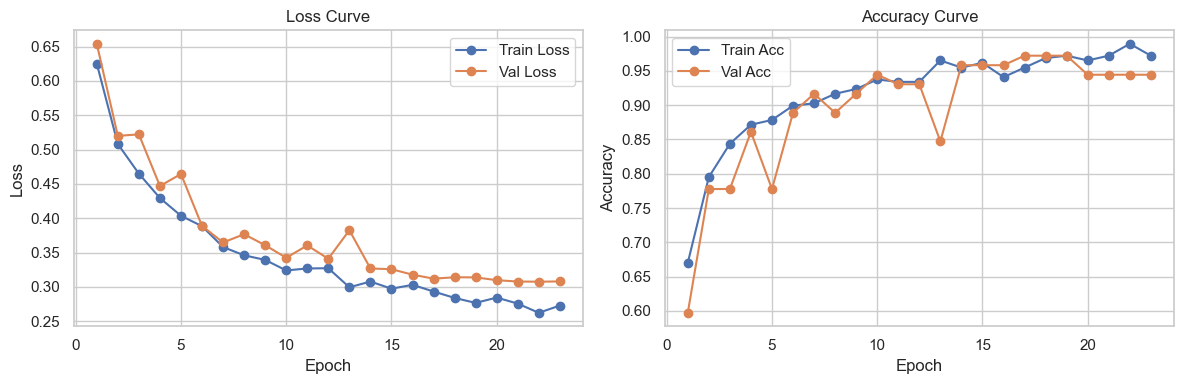

In [56]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_ran = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs_ran, history["train_loss"], marker="o", label="Train Loss")
axes[0].plot(epochs_ran, history["val_loss"], marker="o", label="Val Loss")
axes[0].set_title("Loss Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_ran, history["train_acc"], marker="o", label="Train Acc")
axes[1].plot(epochs_ran, history["val_acc"], marker="o", label="Val Acc")
axes[1].set_title("Accuracy Curve")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [57]:
# Predictions
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(DEVICE)
        logits = model(inputs)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# Classification report
print("📊 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=["Wildlife", "Threat"]))

📊 Classification Report:
              precision    recall  f1-score   support

    Wildlife       0.97      0.97      0.97        40
      Threat       0.97      0.97      0.97        32

    accuracy                           0.97        72
   macro avg       0.97      0.97      0.97        72
weighted avg       0.97      0.97      0.97        72



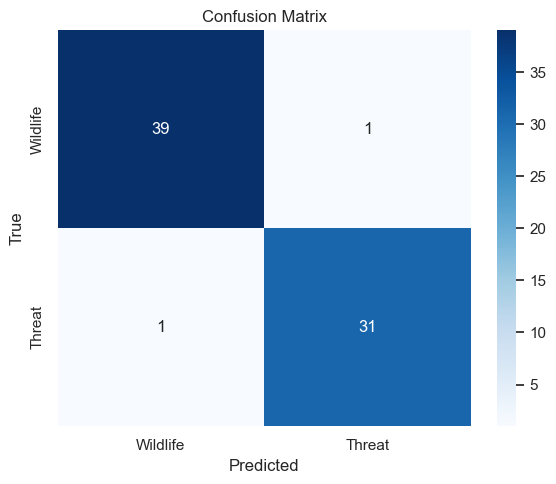

In [58]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Wildlife", "Threat"], yticklabels=["Wildlife", "Threat"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

## 12. Export Model Artifacts

In [59]:
# Save best model
model_path = MODELS_DIR / "forestguard_cnn.pt"
torch.save(best_model_state, model_path)
print(f"✅ Model saved to: {model_path}")

# Verify artifacts
print(f"\n📁 Exported artifacts:")
print(f"  - Model: {model_path}")
print(f"  - Label map: {MODELS_DIR / 'label_map.json'}")
print(f"  - Norm stats: {PROCESSED_DIR / 'norm_stats.npz'}")

# Load and verify label map
with open(MODELS_DIR / "label_map.json", "r") as f:
    lm = json.load(f)
    print(f"\n🏷️ Label map: {lm}")

print("\n🎉 All artifacts ready for deployment!")

✅ Model saved to: d:\CDAC_PROJECT\forestguard\models\forestguard_cnn.pt

📁 Exported artifacts:
  - Model: d:\CDAC_PROJECT\forestguard\models\forestguard_cnn.pt
  - Label map: d:\CDAC_PROJECT\forestguard\models\label_map.json
  - Norm stats: d:\CDAC_PROJECT\forestguard\dataset\processed\norm_stats.npz

🏷️ Label map: {'0': 'Wildlife', '1': 'Threat'}

🎉 All artifacts ready for deployment!


In [60]:
np.savez("models/norm_stats.npz", mean=mean_val, std=std_val)